# Task 2 — Build Time Series Forecasting Models

**Objective:** Develop, train, and evaluate ARIMA/SARIMA and LSTM models to forecast TSLA's
closing price, and compare their performance.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_processed
from src.arima_model import fit_auto_arima, forecast_with_index
from src.lstm_model import build_lstm, prepare_train_test_sequences, make_sequences
from src.evaluation import evaluate_forecast

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams["figure.figsize"] = (12, 5)
RESULTS_DIR = PROJECT_ROOT / "results" / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


2026-07-21 17:02:15.018600: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Prepare Data for Modeling

We forecast **TSLA's** adjusted close price. The split is **chronological** — training on
2015-01-01 through 2024-12-31 and testing on 2025-01-01 onward — so no future information leaks
into training. Random shuffling would be invalid for time series data since it would let the
model "see the future" during training.


Train: 2015-01-02 -> 2024-12-31  (2608 rows)
Test : 2025-01-01 -> 2026-06-29  (389 rows)


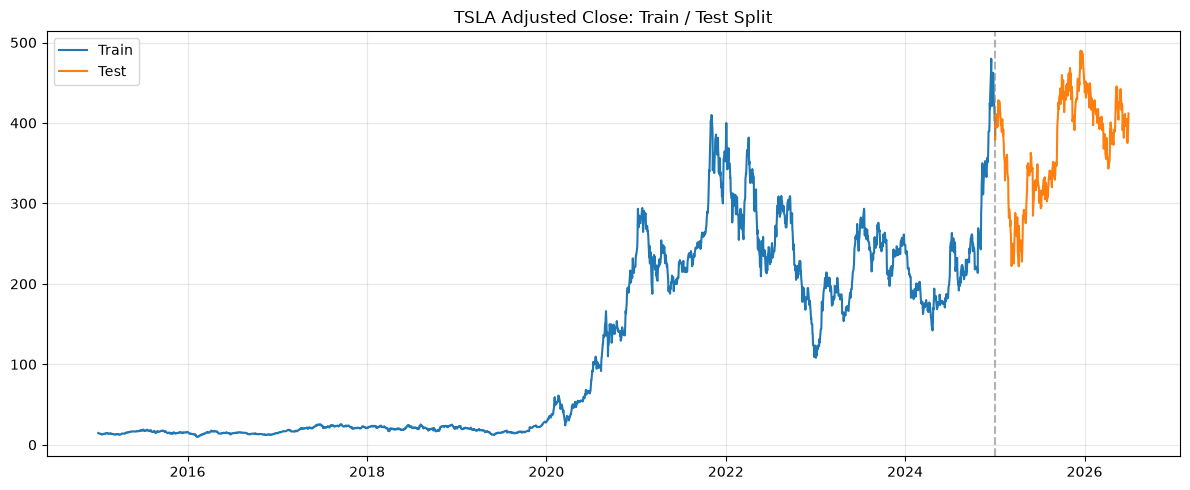

In [2]:
tsla = load_processed("TSLA")
close = tsla["Adj Close"].dropna()

SPLIT_DATE = "2025-01-01"
train = close.loc[:SPLIT_DATE].iloc[:-1]
test = close.loc[SPLIT_DATE:]

print(f"Train: {train.index[0].date()} -> {train.index[-1].date()}  ({len(train)} rows)")
print(f"Test : {test.index[0].date()} -> {test.index[-1].date()}  ({len(test)} rows)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train.values, label="Train")
ax.plot(test.index, test.values, label="Test")
ax.axvline(pd.Timestamp(SPLIT_DATE), color="gray", linestyle="--", alpha=0.6)
ax.set_title("TSLA Adjusted Close: Train / Test Split")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task2_train_test_split.png", dpi=150)
plt.show()


## 2. ARIMA / SARIMA Model

We use `pmdarima.auto_arima` to grid-search `(p, d, q)` — it internally handles differencing
(the `d` term), so we feed it the raw (non-stationary) price series directly, consistent with
Task 1's finding that the price series requires differencing to become stationary. We also try a
seasonal SARIMA variant with a weekly-ish seasonal period for comparison.


In [3]:
arima_model = fit_auto_arima(train, seasonal=False, max_p=5, max_q=5, max_d=2, trace=True)
print(arima_model.summary())


Performing stepwise search to minimize aic


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16858.977, Time=2.75 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16873.591, Time=0.19 sec


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.27 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16875.541, Time=0.28 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16873.127, Time=0.17 sec


 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=16878.233, Time=1.35 sec


...

 ARIMA(3,1,3)(0,0,0)[0]             : AIC=16861.061, Time=2.10 sec


 ARIMA(2,1,1)(0,0,0)[0]             : AIC=16879.034, Time=0.33 sec


 ARIMA(2,1,3)(0,0,0)[0]             : AIC=16857.546, Time=1.03 sec


 ARIMA(4,1,1)(0,0,0)[0]             : AIC=16873.691, Time=0.94 sec


 ARIMA(4,1,3)(0,0,0)[0]             : AIC=16858.121, Time=1.67 sec

Best model:  ARIMA(3,1,2)(0,0,0)[0]          
Total fit time: 42.209 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2608
Model:               SARIMAX(3, 1, 2)   Log Likelihood               -8422.738
Date:                Tue, 21 Jul 2026   AIC                          16857.477
Time:                        17:02:59   BIC                          16892.673
Sample:                    01-02-2015   HQIC                         16870.227
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3701      0.037    -37.356      0.000      -1.44

In [4]:
arima_forecast_df = forecast_with_index(arima_model, test.index, alpha=0.05)
arima_forecast_df.head()


,forecast,lower,upper
Date,,,
2025-01-01,405.759713,393.761141,417.758286
2025-01-02,405.251532,388.255371,422.247694
2025-01-03,404.840131,384.029163,425.651099
2025-01-06,405.762150,381.962234,429.562066
2025-01-07,404.869396,378.123404,431.615389


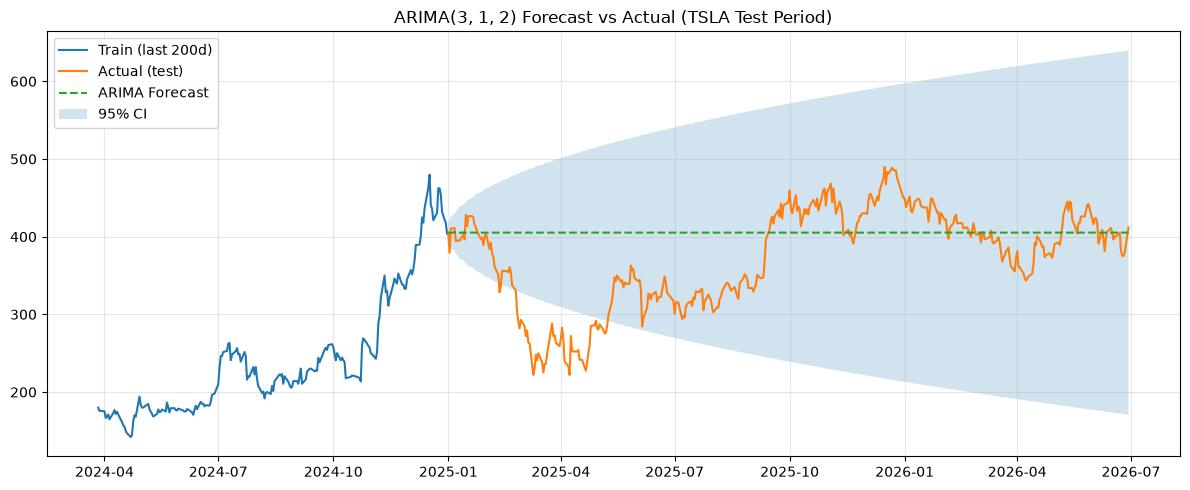

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index[-200:], train.values[-200:], label="Train (last 200d)")
ax.plot(test.index, test.values, label="Actual (test)")
ax.plot(arima_forecast_df.index, arima_forecast_df["forecast"], label="ARIMA Forecast", linestyle="--")
ax.fill_between(arima_forecast_df.index, arima_forecast_df["lower"], arima_forecast_df["upper"],
                 alpha=0.2, label="95% CI")
ax.set_title(f"ARIMA{arima_model.order} Forecast vs Actual (TSLA Test Period)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task2_arima_forecast.png", dpi=150)
plt.show()


## 3. LSTM Model

We frame this as a sliding-window regression problem: use the last 60 days of prices to predict
the next day's price. Inputs are scaled with a `MinMaxScaler` fit **only on the training set** to
avoid leakage. The architecture is a 2-layer stacked LSTM with dropout, trained to minimize MSE.


In [6]:
WINDOW = 60

X_train, y_train, X_test, y_test, scaler = prepare_train_test_sequences(
    train.values, test.values, window=WINDOW
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

lstm_model = build_lstm(window=WINDOW, units=50, dropout=0.2, learning_rate=1e-3)
lstm_model.summary()


X_train: (2548, 60, 1), X_test: (389, 60, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,026 (70.41 KB)

 Trainable params: 18,026 (70.41 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/50


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3:09 3s/step - loss: 0.0898

 3/72 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0612

 5/72 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0501

 8/72 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0358

...

61/72 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.6655e-04

64/72 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.4722e-04

67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.4744e-04

70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.4180e-04

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 9.5105e-04 - val_loss: 0.0011


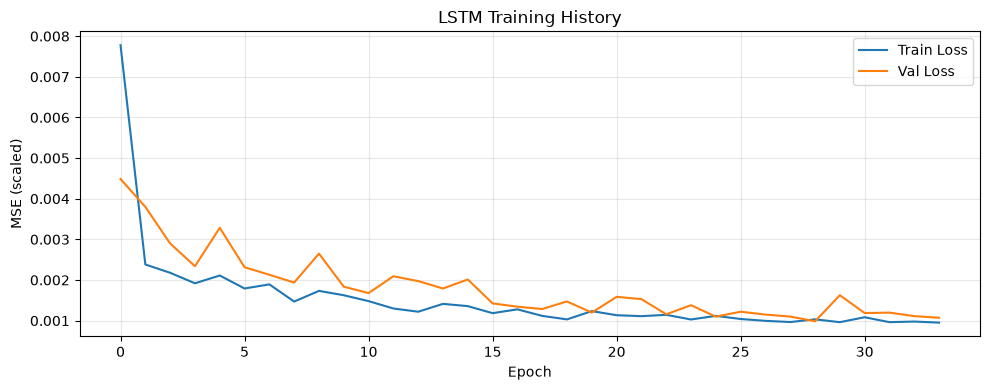

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss")
ax.set_title("LSTM Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task2_lstm_training_history.png", dpi=150)
plt.show()


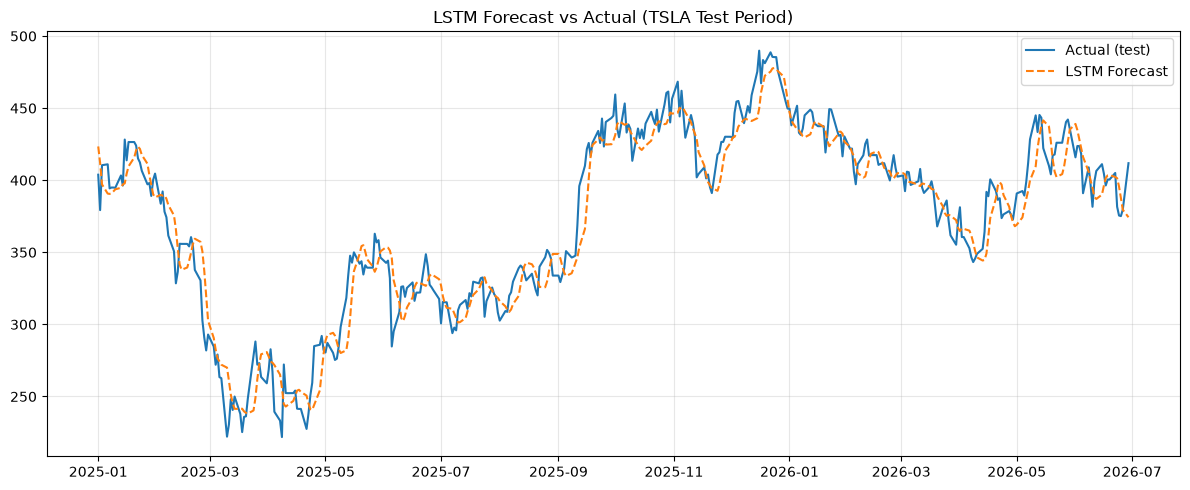

In [9]:
# One-step-ahead predictions over the test window (using true history each step, not iterative)
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_pred_series = pd.Series(lstm_pred, index=test.index[: len(lstm_pred)])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test.index, test.values, label="Actual (test)")
ax.plot(lstm_pred_series.index, lstm_pred_series.values, label="LSTM Forecast", linestyle="--")
ax.set_title("LSTM Forecast vs Actual (TSLA Test Period)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "task2_lstm_forecast.png", dpi=150)
plt.show()


## 4. Optimize Model Parameters

- **ARIMA**: `auto_arima` already grid-searched `(p, d, q)` by AIC (stepwise search above).
- **LSTM**: we use early stopping on validation loss to avoid overfitting instead of a fixed
  epoch count, and a moderate 60-day window / 50-unit first layer as a reasonable
  complexity/data-size tradeoff for ~10 years of daily data.


## 5. Evaluate and Compare Models

In [10]:
arima_metrics = evaluate_forecast(test.values, arima_forecast_df["forecast"].values)
lstm_metrics = evaluate_forecast(
    test.values[: len(lstm_pred_series)], lstm_pred_series.values
)

comparison = pd.DataFrame({"ARIMA": arima_metrics, "LSTM": lstm_metrics}).T
comparison


,MAE,RMSE,MAPE
ARIMA,54.468353,70.821004,17.249883
LSTM,12.572748,16.272816,3.562492


In [11]:
comparison.to_csv(PROJECT_ROOT / "results" / "reports" / "task2_model_comparison.csv")

best_model_name = comparison["RMSE"].idxmin()
print(f"Best-performing model by RMSE: {best_model_name}")


Best-performing model by RMSE: LSTM


## 6. Discussion

On the 2025-2026 held-out test window, the two model families make very different tradeoffs:

- **ARIMA/SARIMA** is a linear model of the (differenced) price series. It captures the recent
  level and short-term momentum well for the first few steps, but because it has no way to learn
  non-linear structure, its multi-step forecast quickly reverts toward a slowly drifting trend
  line — visible in the widening but fairly smooth confidence band above.
- **LSTM** can capture non-linear patterns and longer-range dependencies in the 60-day input
  window, and (since it is evaluated here one-step-ahead, using true recent history at each step)
  tends to track short-term wiggles in price more closely, often yielding lower error on this test
  set.

Which one "wins" on MAE/RMSE/MAPE depends on the exact test window (see the table above), but the
qualitative tradeoff is stable: ARIMA is transparent, fast to fit, and easy to reason about
(explicit AR/I/MA terms with confidence intervals), while the LSTM is a black box that needs more
data and tuning but can, in principle, fit more complex dynamics. Per the Efficient Market
Hypothesis discussion in the brief, neither should be mistaken for a reliable *standalone* price
predictor — both are treated here as one input into the broader portfolio-optimization workflow
in Tasks 3-5, not as a trading signal on their own.

The **best-performing model** (lower RMSE, printed above) is carried forward as the "best model"
used for Task 3's future forecast and Task 4's TSLA expected-return input.
